Organizations and job seekers lack a centralized, data-driven view of labor market trends, making it difficult to identify in-demand skills, salary expectations, and emerging opportunities.


**Objective 1: Salary Intelligence**
Questions to answer
Which job titles pay the highest salaries?
Which job categories pay the most?
What is the salary distribution across roles?
What are the salary ranges for different positions?
Insights

Examples:

Data Scientists earn more than Data Analysts.
Software Engineers have wider salary ranges.
Some categories show higher salary variability.

This is likely your strongest objective because salary data is available.

**Objective 2: Geographic Opportunity Analysis**
Questions
Which locations have the most openings?
Which locations offer the highest salaries?
Which regions specialize in certain job categories?
Insights

Examples:

London has more Data Analyst jobs.
Manchester offers competitive salaries in specific categories.
Some locations have many openings but lower pay.
Objective 3: Employer Hiring Analysis
Questions
Which companies post the most jobs?
Which companies offer the highest salaries?
Which categories are most common for each employer?
Insights

Examples:

Certain employers dominate hiring.
Some employers consistently advertise higher salary ranges.
Objective 4: Category Demand Analysis
Questions
Which job categories have the most openings?
Which categories pay the highest salaries?
Which categories show the largest salary spread?
Insights

Examples:

IT Jobs may have the highest volume.
Engineering roles may have higher median salaries.
Objective 5: Job Title Analysis
Questions
Most common job titles?
Highest-paying job titles?
Salary variation within the same title?
Insights

Examples:

Senior roles command significantly higher salaries.
Some titles have large salary variability.

In [1]:
import requests
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import userdata
job_key=userdata.get('job_key')
job_app_id=userdata.get('job_app_id')

In [3]:
# @title
def fetch_job_listings(app_id: str, app_key: str,
                       search_query: str,
                       #location :str ,
                       start_page_number :int = 1,
                       end_page_number : int =20 ,
                       country: str = 'us') -> dict:
    all_responses = []
    for page in range(start_page_number, end_page_number+1):
      base_url = f"https://api.adzuna.com/v1/api/jobs/{country}/search/{page}"
      parameters = {
        'app_id': app_id,
        'app_key': app_key,
        'what': search_query,
        #'where': location,
        'content-type': 'application/json'
      }
      response = requests.get(base_url, params=parameters)
      if response.status_code == 200:
          data = response.json()
          all_responses.extend(data.get('results', []))
    return all_responses

In [4]:
# @title
import json

def parse_response(response: dict):
    if 'results' in response:
        for job in response['results']:
            job_title = job.get('title', 'N/A')
            company = job.get('company', {}).get('display_name', 'N/A')
            #location = job.get('location', {}).get('display_name', 'N/A')
            print(f"Job Title: {job_title}, Company: {company}")
    else:
        print("No results found or an error occurred.")

In [5]:
# @title
app_id = job_app_id
app_key = job_key
search_query = 'Software'
#location = 'new york'


job_listing_response_data = fetch_job_listings(app_id, app_key,search_query,end_page_number = 100)
parse_response(job_listing_response_data)
#job_listing_response_data

No results found or an error occurred.


In [6]:
job_listing_response_data

[{'__CLASS__': 'Adzuna::API::Response::Job',
  'location': {'display_name': 'King of Prussia, Montgomery County',
   '__CLASS__': 'Adzuna::API::Response::Location',
   'area': ['US', 'Pennsylvania', 'Montgomery County', 'King of Prussia']},
  'description': "Job Description: Are you ready to unlock the full potential of Artificial Intelligence and be part of a team that's revolutionizing the industry? Look no further! The Lockheed Martin Artificial Intelligence Center (LAIC) team is seeking a highly motivated and experienced individual to join our Applied AI team, specifically the STAR.OS portfolio. As a key member of our team, you'll have the opportunity to work on a wide range of projects, from prototypes to deployment, and contribute to the deve…",
  'latitude': 40.095652,
  'category': {'label': 'IT Jobs',
   '__CLASS__': 'Adzuna::API::Response::Category',
   'tag': 'it-jobs'},
  'id': '5764812120',
  'salary_max': 198504,
  'adref': 'eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTc2NDgxMjEyMCIsIn

In [7]:
# @title
# # @title
# def fetch_all_categories(app_id : str, app_key : str , country : str = 'us') -> dict :
#   base_url=f"https://api.adzuna.com/v1/api/jobs/{country}/categories"
#   parameters = {
#       "app_id" : app_id,
#       "app_key" : app_key,
#       "content-type": 'application/json'
#   }
#   response = requests.get(base_url,params=parameters)
#   return response.json()

In [8]:
# @title
# # @title
# def parse_response(response:dict):
#   if 'results' in response:
#     for job in response['results']:
#       job_category= job.get('label', 'N/A')
#       print(f"Category: {job_category}")
#     else:
#       print("No results found")

In [9]:
# @title
# # @title
# app_id=job_app_id
# api_key=job_key
# response_data= fetch_all_categories(app_id, api_key)
# parse_response(response_data)

In [10]:
job_listing_response_data
df= pd.json_normalize(job_listing_response_data)

In [11]:
df.to_csv('jobs.csv',index=False)

In [12]:
#raw_df = df.copy()
model_df = df.copy()

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   __CLASS__              1000 non-null   object 
 1   description            1000 non-null   object 
 2   latitude               992 non-null    float64
 3   id                     1000 non-null   object 
 4   salary_max             1000 non-null   float64
 5   adref                  1000 non-null   object 
 6   salary_is_predicted    1000 non-null   object 
 7   salary_min             1000 non-null   float64
 8   created                1000 non-null   object 
 9   contract_time          158 non-null    object 
 10  title                  1000 non-null   object 
 11  redirect_url           1000 non-null   object 
 12  longitude              992 non-null    float64
 13  location.display_name  1000 non-null   object 
 14  location.__CLASS__     1000 non-null   object 
 15  locat

In [14]:
df.columns

Index(['__CLASS__', 'description', 'latitude', 'id', 'salary_max', 'adref',
       'salary_is_predicted', 'salary_min', 'created', 'contract_time',
       'title', 'redirect_url', 'longitude', 'location.display_name',
       'location.__CLASS__', 'location.area', 'category.label',
       'category.__CLASS__', 'category.tag', 'company.__CLASS__',
       'company.display_name', 'contract_type'],
      dtype='object')

In [15]:
#job_listing_response_data
df.head(1)

,__CLASS__,description,latitude,id,salary_max,adref,salary_is_predicted,salary_min,created,contract_time,...,longitude,location.display_name,location.__CLASS__,location.area,category.label,category.__CLASS__,category.tag,company.__CLASS__,company.display_name,contract_type
0,Adzuna::API::Response::Job,Job Description: Are you ready to unlock the f...,40.095652,5764812120,198504.0,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTc2NDgxMjEyMCIsI...,1,198504.0,2026-06-15T20:13:30Z,part_time,...,-75.3738,"King of Prussia, Montgomery County",Adzuna::API::Response::Location,"[US, Pennsylvania, Montgomery County, King of ...",IT Jobs,Adzuna::API::Response::Category,it-jobs,Adzuna::API::Response::Company,Lockheed Martin,NaN


In [16]:
df = df.drop(columns = ['id' , 'description' ,'adref','redirect_url','redirect_url','__CLASS__',
                        'company.__CLASS__','location.__CLASS__',
                        'category.__CLASS__','category.tag'])
df.head(10)

,latitude,salary_max,salary_is_predicted,salary_min,created,contract_time,title,longitude,location.display_name,location.area,category.label,company.display_name,contract_type
0,40.095652,198504.00,1,198504.00,2026-06-15T20:13:30Z,part_time,AI Software Engineer,-75.373800,"King of Prussia, Montgomery County","[US, Pennsylvania, Montgomery County, King of ...",IT Jobs,Lockheed Martin,NaN
1,32.758760,174133.47,1,174133.47,2026-06-07T12:32:51Z,part_time,Cleared Software Engineer,-97.323160,"Fort Worth, Tarrant County","[US, Texas, Tarrant County, Fort Worth]",IT Jobs,Lockheed Martin,NaN
2,39.132050,203357.95,1,203357.95,2026-06-22T22:29:57Z,full_time,Software Engineer with Poly SR SWE2,-76.799422,"Savage, Anne Arundel County","[US, Maryland, Anne Arundel County, Savage]",IT Jobs,Lockheed Martin,NaN
3,40.095652,213169.75,1,213169.75,2026-05-31T21:25:29Z,part_time,"Senior Software Engineer, STAR.UI (Mission Aut...",-75.373800,"King of Prussia, Montgomery County","[US, Pennsylvania, Montgomery County, King of ...",IT Jobs,Lockheed Martin,NaN
4,33.829187,114526.71,1,114526.71,2026-05-14T02:52:50Z,NaN,Senior Software Engineer,-118.316971,"Torrance, Los Angeles County","[US, California, Los Angeles County, Torrance]",Engineering Jobs,3DEO,NaN
5,32.398932,90849.52,1,90849.52,2026-06-23T00:09:57Z,NaN,Software Programmer,-86.322464,"Montgomery, Montgomery County","[US, Alabama, Montgomery County, Montgomery]",IT Jobs,Cornerstone Detention Products,NaN
6,39.845450,134834.17,1,134834.17,2026-06-22T02:04:05Z,full_time,Software Engineer (MES),-75.372202,"Eddystone, Delaware County","[US, Pennsylvania, Delaware County, Eddystone]",IT Jobs,L3Harris Technologies,NaN
7,39.219878,80993.18,1,80993.18,2026-06-22T02:04:05Z,full_time,"Lead, Software Engineer",-77.403109,"Dickerson, Montgomery County","[US, Maryland, Montgomery County, Dickerson]",IT Jobs,L3Harris Technologies,NaN
8,38.681368,101046.53,1,101046.53,2026-06-22T02:04:07Z,full_time,"Lead, Software Engineer",-77.261276,"Occoquan, Prince William County","[US, Virginia, Prince William County, Occoquan]",IT Jobs,L3Harris Technologies,NaN
9,38.946620,86890.59,1,86890.59,2026-06-22T02:04:06Z,full_time,"Lead, Software Engineer",-77.365920,"Reston, Fairfax County","[US, Virginia, Fairfax County, Reston]",IT Jobs,L3Harris Technologies,NaN


In [17]:
df.columns

Index(['latitude', 'salary_max', 'salary_is_predicted', 'salary_min',
       'created', 'contract_time', 'title', 'longitude',
       'location.display_name', 'location.area', 'category.label',
       'company.display_name', 'contract_type'],
      dtype='object')

In [18]:
df.isnull().sum()

,0
latitude,8
salary_max,0
salary_is_predicted,0
salary_min,0
created,0
contract_time,842
title,0
longitude,8
location.display_name,0
location.area,0


In [19]:
df = df.drop(columns = ['contract_time' , 'contract_type','latitude' ,'salary_is_predicted',
                        'location.display_name','longitude','created'])
df.head()

,salary_max,salary_min,title,location.area,category.label,company.display_name
0,198504.00,198504.00,AI Software Engineer,"[US, Pennsylvania, Montgomery County, King of ...",IT Jobs,Lockheed Martin
1,174133.47,174133.47,Cleared Software Engineer,"[US, Texas, Tarrant County, Fort Worth]",IT Jobs,Lockheed Martin
2,203357.95,203357.95,Software Engineer with Poly SR SWE2,"[US, Maryland, Anne Arundel County, Savage]",IT Jobs,Lockheed Martin
3,213169.75,213169.75,"Senior Software Engineer, STAR.UI (Mission Aut...","[US, Pennsylvania, Montgomery County, King of ...",IT Jobs,Lockheed Martin
4,114526.71,114526.71,Senior Software Engineer,"[US, California, Los Angeles County, Torrance]",Engineering Jobs,3DEO


In [20]:
df['salary_max']= df['salary_max'].fillna(df['salary_min'])

In [21]:
df[df.isna().any(axis=1)]

,salary_max,salary_min,title,location.area,category.label,company.display_name


In [22]:
df['salary'] =(df['salary_max'] + df['salary_min'])/2

In [23]:
df=df.drop(columns = ['salary_max','salary_min'])

In [24]:
df.head(1)

,title,location.area,category.label,company.display_name,salary
0,AI Software Engineer,"[US, Pennsylvania, Montgomery County, King of ...",IT Jobs,Lockheed Martin,198504.0


In [25]:
df_salary_by_title = df.groupby('title')['salary'].mean()

In [26]:
df_salary_by_title= df_salary_by_title.to_frame()

In [27]:
df_salary_by_title.reset_index()

,title,salary
0,2026 Associate Software Engineer / Software En...,78492.220000
1,AI Software Engineer,149501.333333
2,Appian Software Developer/Integrator,134510.993636
3,Associate CNO Software Developer,135000.000000
4,"Associate Manager, Software Engineer",101071.464000
...,...,...
58,"Specialist, DevSecOps Cloud Software Engineer",67509.152500
59,"Specialist, Software Engineer (Cloud Web Devel...",99517.208000
60,"Specialist, Software Engineering",85761.394000
61,Technical Manager - Software Engineering,182724.144000


In [28]:
df_salary_by_title= df_salary_by_title.sort_values(by='salary',ascending = False)

In [29]:
# #Job categories which pay the most
# df_salary_by_category = df[['category.label','salary']]
# df_salary_by_category= df_salary_by_category.groupby('category.label')['salary'].mean()
# df_salary_by_category

In [30]:
# df_salary_by_category= df_salary_by_category.to_frame()
# df_salary_by_category.reset_index()
# df_salary_by_category = df_salary_by_category.sort_values(by='salary',ascending= False)
# df_salary_by_category = df_salary_by_category.head(10)
# df_salary_by_category

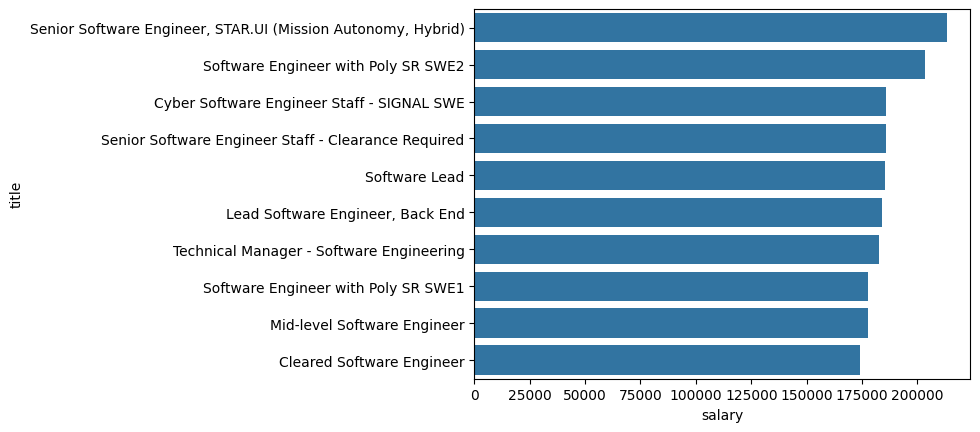

In [31]:
sns.barplot(data=df_salary_by_title.head(10) ,x='salary', y ="title", orient="h")
plt.show()

In [32]:
df_salary_by_title = df_salary_by_title.reset_index()

In [33]:
#Remove common separators like hyphen commas and /
df[['title' ,'description']] = df['title'].str.split(r'/|,', expand =True,n=1)

In [34]:
df['title']= df['title'].str.strip('()')
df['title']= df['title'].str.replace(r'\(|\)', '', regex=True)

In [35]:
df.rename(columns = {'category.label':'category','location.area':'location' , 'company.display_name':'company'} ,inplace= True)

In [36]:
df["location"] = df["location"].str.join(", ")

In [37]:
df=df.drop(columns = ['description'])
df.head(10)

,title,location,category,company,salary
0,AI Software Engineer,"US, Pennsylvania, Montgomery County, King of P...",IT Jobs,Lockheed Martin,198504.00
1,Cleared Software Engineer,"US, Texas, Tarrant County, Fort Worth",IT Jobs,Lockheed Martin,174133.47
2,Software Engineer with Poly SR SWE2,"US, Maryland, Anne Arundel County, Savage",IT Jobs,Lockheed Martin,203357.95
3,Senior Software Engineer,"US, Pennsylvania, Montgomery County, King of P...",IT Jobs,Lockheed Martin,213169.75
4,Senior Software Engineer,"US, California, Los Angeles County, Torrance",Engineering Jobs,3DEO,114526.71
5,Software Programmer,"US, Alabama, Montgomery County, Montgomery",IT Jobs,Cornerstone Detention Products,90849.52
6,Software Engineer MES,"US, Pennsylvania, Delaware County, Eddystone",IT Jobs,L3Harris Technologies,134834.17
7,Lead,"US, Maryland, Montgomery County, Dickerson",IT Jobs,L3Harris Technologies,80993.18
8,Lead,"US, Virginia, Prince William County, Occoquan",IT Jobs,L3Harris Technologies,101046.53
9,Lead,"US, Virginia, Fairfax County, Reston",IT Jobs,L3Harris Technologies,86890.59


In [38]:
df[['country' , 'state' , 'county','town']] = df['location'].str.split(r',',expand =True,n=3)

In [39]:
df= df.drop(columns = ['country','location'])
df.head(1)

,title,category,company,salary,state,county,town
0,AI Software Engineer,IT Jobs,Lockheed Martin,198504.0,Pennsylvania,Montgomery County,King of Prussia


In [40]:
df.head(1)

,title,category,company,salary,state,county,town
0,AI Software Engineer,IT Jobs,Lockheed Martin,198504.0,Pennsylvania,Montgomery County,King of Prussia


In [41]:
raw_df = df.copy()

In [42]:
from sklearn.preprocessing import LabelEncoder

In [43]:
c=df.columns.to_list()

In [44]:
c

['title', 'category', 'company', 'salary', 'state', 'county', 'town']

In [45]:
title_encoder = LabelEncoder()
company_encoder = LabelEncoder()
category_encoder = LabelEncoder()
state_encoder = LabelEncoder()
county_encoder = LabelEncoder()
town_encoder = LabelEncoder()

df['title'] = title_encoder.fit_transform(df['title'])
df['company'] = company_encoder.fit_transform(df['company'])
df['category'] = category_encoder.fit_transform(df['category'])
df['state'] = state_encoder.fit_transform(df['state'])
df['county'] = county_encoder.fit_transform(df['county'])
df['town'] = town_encoder.fit_transform(df['town'])

In [46]:
x = df.drop(columns = ['salary'])
x.head(1)

,title,category,company,state,county,town
0,1,1,13,34,109,280


In [47]:
x1=df.drop(columns = ['town','salary'])

In [48]:
y=df['salary']
y.head(1)

,salary
0,198504.0


In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x1,y,test_size=0.25)

In [50]:
lr= LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [51]:
y_pred = lr.predict(x_test)

In [52]:
from sklearn.metrics import r2_score , confusion_matrix , mean_absolute_error , root_mean_squared_error
r2_score(y_test,y_pred)

0.15596801893731582

In [53]:
from sklearn.ensemble import RandomForestRegressor

In [54]:
rf= RandomForestRegressor()
rf.fit(x_train,y_train)

RandomForestRegressor()

In [55]:
y_pred = rf.predict(x_test)

In [56]:
print("R2 score :",r2_score(y_test,y_pred))
print("RMSE :", root_mean_squared_error(y_test,y_pred))
print("MAE  :" ,mean_absolute_error(y_test,y_pred))

R2 score : 0.8496999278129713
RMSE : 19358.597336320352
MAE  : 13801.656849070914


In [57]:
state_encoder.classes_

array([' Alabama', ' Alaska', ' Arizona', ' Arkansas', ' California',
       ' Colorado', ' Connecticut', ' Delaware', ' Florida', ' Georgia',
       ' Hawaii', ' Idaho', ' Illinois', ' Indiana', ' Iowa', ' Kansas',
       ' Kentucky', ' Louisiana', ' Maine', ' Maryland', ' Massachusetts',
       ' Michigan', ' Mississippi', ' Missouri', ' Montana', ' Nebraska',
       ' New Hampshire', ' New Jersey', ' New Mexico', ' New York',
       ' North Carolina', ' North Dakota', ' Oklahoma', ' Oregon',
       ' Pennsylvania', ' Rhode Island', ' South Carolina', ' Tennessee',
       ' Texas', ' Utah', ' Vermont', ' Virginia', ' Washington',
       ' West Virginia', ' Wisconsin', ' Wyoming', None], dtype=object)

In [71]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 103.2 MB/s eta 0:00:00


In [ ]:
# # import ipywidgets as widgets
# # from IPython.display import display
# import streamlit as st

# title_dropdown = st.selectbox(
#     options=sorted(title_encoder.classes_),
#     label = 'Job title',
#     placeholder= 'Title:'
# )
# company_dropdown = st.selectbox(
#     options=sorted(company_encoder.classes_),
#     label = 'company',
#     placeholder= 'company'
# )

# category_dropdown = st.selectbox(
#     options=sorted(category_encoder.classes_),
#     label = 'category',
#     placeholder = 'category'
# )

# state_dropdown = st.selectbox(
#     options=sorted([x for x in state_encoder.classes_ if x is not None]),
#     label = 'state',
#     placeholder= 'State'
# )
# county_dropdown = st.selectbox(
#     options=[],
#     label = 'County',
#     placeholder= 'County:'

# )


# # title_dropdown = widgets.Dropdown(
# #     options=sorted(title_encoder.classes_),
# #     description='Title:'
# # )

# # company_dropdown = widgets.Dropdown(
# #     options=sorted(company_encoder.classes_),
# #     description='Company:'
# # )

# # category_dropdown = widgets.Dropdown(
# #     options=sorted(category_encoder.classes_),
# #     description='Category:'
# # )

# # state_dropdown = widgets.Dropdown(
# #     options=sorted([x for x in state_encoder.classes_ if x is not None]),
# #     description='State:'
# # )
# # county_dropdown = widgets.Dropdown(
# #     options=[],
# #     description='County:'
# # )



2026-06-24 13:09:20.508 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 13:09:20.509 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 13:09:20.510 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 13:09:20.512 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 13:09:20.513 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 13:09:20.515 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 13:09:20.515 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 13:09:20.517 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
# def update_counties(change):
#     selected_state = change['new']

#     counties = (
#         raw_df.loc[
#             raw_df['state'] == selected_state,
#             'county'
#         ]
#         .dropna()
#         .unique()
#     )

#     county_dropdown.options = sorted(counties)

# state_dropdown.observe(update_counties, names='value')

# def update_titles(change):
#     selected_company = change['new']

#     title = (
#         raw_df.loc[
#             raw_df['company'] == selected_company,
#             'title'
#         ]
#         .dropna()
#         .unique()
#     )

#     title_dropdown.options = sorted(title)

# company_dropdown.observe(update_titles, names='value')

In [ ]:
# def update_category(change):
#     selected_title = change['new']

#     category = (
#         raw_df.loc[
#             raw_df['title'] == selected_title,
#             'category'
#         ]
#         .dropna()
#         .unique()
#     )

#     category_dropdown.options = sorted(category)

# title_dropdown.observe(update_category, names='value')

In [ ]:
# display(company_dropdown, title_dropdown , category_dropdown)
# display(state_dropdown, county_dropdown)

Dropdown(description='Company:', options=('3DEO', 'A&M Technologies, Inc.', 'Black Creek Integrated Systems', …

Dropdown(description='Title:', options=('2026 Associate Software Engineer ', 'AI Software Engineer', 'Appian S…

Dropdown(description='Category:', options=('Engineering Jobs', 'IT Jobs', 'Teaching Jobs'), value='Engineering…

Dropdown(description='State:', options=(' Alabama', ' Alaska', ' Arizona', ' Arkansas', ' California', ' Color…

Dropdown(description='County:', options=(), value=None)

In [ ]:
# title_val = title_encoder.transform([title_dropdown.value])[0]
# company_val = company_encoder.transform([company_dropdown.value])[0]
# category_val = category_encoder.transform([category_dropdown.value])[0]
# state_val = state_encoder.transform([state_dropdown.value])[0]
# county_val = county_encoder.transform([county_dropdown.value])[0]

In [ ]:
# new_job = [[
#     title_val,
#     company_val,
#     category_val,
#     state_val,
#     county_val,
# ]]

In [64]:
predicted_salary = rf.predict(new_job)[0]
print(f"Predicted Salary: £{predicted_salary:,.0f}")

Predicted Salary: £117,650


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [65]:
import joblib
joblib.dump(rf , 'salary_predictor.pkl')

joblib.dump(title_encoder, 'title_encoder.pkl')
joblib.dump(company_encoder, 'company_encoder.pkl')
joblib.dump(category_encoder, 'category_encoder.pkl')
joblib.dump(state_encoder, 'state_encoder.pkl')
joblib.dump(county_encoder, 'county_encoder.pkl')

['county_encoder.pkl']

In [66]:
rf = joblib.load('salary_predictor.pkl')

title_encoder = joblib.load('title_encoder.pkl')
company_encoder = joblib.load('company_encoder.pkl')
category_encoder = joblib.load('category_encoder.pkl')
state_encoder = joblib.load('state_encoder.pkl')
county_encoder = joblib.load('county_encoder.pkl')

In [67]:
# from google.colab import files

# files.download('salary_predictor.pkl')
# files.download('title_encoder.pkl')
# files.download('company_encoder.pkl')
# files.download('state_encoder.pkl')
# files.download('category_encoder.pkl')
# files.download('county_encoder.pkl')

In [68]:
# raw_df.to_csv('raw_jobs.csv',index = False)